# Модель 3 — обучаемый ре-ранкер (LightGBM, lambdarank)

Поверх кандидатов от модели 1 (BM25, `bm25.py`/`text_prep.py`) с широким
запасом (`CANDIDATE_POOL` кандидатов на запрос вместо финальных 50),
обогащённых признаками из `features.py` — включая, если файл есть,
`embed_score` от модели 2 (`02_embed_and_retrieve.ipynb`).

**Идея:** вместо ручных весов (`"BM25 + 40*совпадение_локации"`, как в
`generate_submission.py`) даём модели сырые сигналы (BM25-скор, гео,
категория, рейтинг, цена, и опционально косинус от эмбеддингов) и учим её на
реальных исторических выборах пользователей (`train.parquet`), какую
комбинацию этих сигналов использовать. Это снимает вопрос "как объединить
несколько моделей" — просто добавляете скор новой модели как ещё одну колонку
в `features.py`, и LightGBM сам решает, насколько ему доверять.

Построение обучающих примеров ВЕКТОРИЗОВАНО (`features.flatten_candidates` /
`build_candidate_features_batch`) — на `CANDIDATE_POOL=300 x 15000` запросов
это ~4.5 млн строк признаков, в Python-цикле по запросам это собиралось бы
неприемлемо долго.

**Порядок:**
1. (обязательно) модель 1 не нужно отдельно готовить — BM25 строится тут же.
2. (опционально, но желательно) прогоните `02_embed_and_retrieve.ipynb` в
   режиме train (`QUERY_ID_COL="query_uid"`) — получите
   `embed_candidates_train.parquet`.
3. Запустите ячейки этого ноутбука по порядку → сохранится `reranker_lgb.txt`.

**Оценка:** Recall@50 сравнивается между (a) чистым BM25+гео-бустом (как в
`generate_submission.py`) и (b) LightGBM-ре-ранкером — на ОТЛОЖЕННЫХ запросах,
не пересекающихся с обучающими.

In [1]:
import time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from text_prep import build_query_text, iter_item_texts, stemming_generator
from bm25 import BM25Index
from features import (
    flatten_candidates, build_candidate_features_batch,
    precompute_item_arrays, precompute_query_arrays,
)
from evaluate_offline import load_train, recall_at_k

## Конфиг

In [2]:
CANDIDATE_POOL = 300     # ширина первой стадии (BM25) - кандидаты для обучения/оценки ре-ранкера
N_TRAIN_QUERIES = 15000  # сколько запросов train используем для обучения LightGBM (None = все)
N_EVAL_QUERIES = 1500    # отложенная часть - для честной оценки (не пересекается с обучающими)
K = 50
SEED = 42

# путь к embed_candidates.parquet, посчитанному 02_embed_and_retrieve.ipynb в РЕЖИМЕ TRAIN
# (QUERIES_FILE=train_queries.parquet, QUERY_ID_COL="query_uid"). Если файла
# нет - обучимся без эмбеддинг-признака (это ок, модель 3 будет опираться на BM25/гео/etc).
TRAIN_EMBED_CANDIDATES_PATH = "./embed_candidates_train.parquet"

## Вспомогательные функции

In [3]:
def load_embed_lookup(path, query_id_dtype=int):
    try:
        df = pd.read_parquet(path)
        df["query_id"] = df["query_id"].astype(query_id_dtype)  # тут это на самом деле query_uid
        return df.set_index(["query_id", "item_id"])["embed_score"]
    except FileNotFoundError:
        print(f"[инфо] {path} не найден - обучаемся без эмбеддинг-признака")
        return None

In [4]:
def build_examples(query_uids, tq, item_arrays, tp, bm25, item_ids, gt, embed_lookup):
    """Векторизованно строит X (признаки), y (label), group (число кандидатов
    на запрос - нужно LightGBM для группировки) для заданного множества query_uid.

    item_arrays - результат precompute_item_arrays(ti), считается ОДИН РАЗ
    (одинаковый и для train, и для eval подмножеств - корпус объявлений один
    и тот же), чтобы не пересчитывать его на каждый вызов."""
    sub_q = tq[tq["query_uid"].isin(query_uids)].reset_index(drop=True)
    qtext = list(stemming_generator(build_query_text(sub_q)))

    top_idx, top_scores = bm25.topk(qtext, k=CANDIDATE_POOL, return_scores=True)
    flat = flatten_candidates(sub_q, top_idx, top_scores, item_ids)

    query_arrays = precompute_query_arrays(sub_q)
    query_ids_for_lookup = sub_q["query_uid"].values

    X = build_candidate_features_batch(
        flat, item_arrays, query_arrays,
        query_ids_for_lookup=query_ids_for_lookup, embed_lookup=embed_lookup,
    )

    query_uid_per_row = sub_q["query_uid"].values[flat["query_pos"]]
    rel_by_uid = gt  # pd.Series query_uid -> set(item_id)
    y = np.zeros(len(flat["item_id"]), dtype=np.int8)
    for uid in np.unique(query_uid_per_row):
        rel = rel_by_uid.get(uid, set())
        if not rel:
            continue
        mask = query_uid_per_row == uid
        y[mask] = np.isin(flat["item_id"][mask], list(rel))

    return X, y, flat["group_sizes"], query_uid_per_row, flat["item_id"]

## Загружаем train, делаем train/eval-разбиение по запросам

In [5]:
tq, ti, tp = load_train()
gt = tp.groupby("query_uid")["item_id"].apply(set)
item_ids = ti["item_id"].values
embed_lookup = load_embed_lookup(TRAIN_EMBED_CANDIDATES_PATH)

rng = np.random.default_rng(SEED)
all_uids = tq["query_uid"].values
eval_uids = rng.choice(all_uids, size=N_EVAL_QUERIES, replace=False)
remaining = np.setdiff1d(all_uids, eval_uids)
n_train = len(remaining) if N_TRAIN_QUERIES is None else min(N_TRAIN_QUERIES, len(remaining))
train_uids = rng.choice(remaining, size=n_train, replace=False)
print(f"train queries: {len(train_uids)}, eval queries: {len(eval_uids)} (не пересекаются)")

train queries: 15000, eval queries: 1500 (не пересекаются)


## Модель 1: BM25 (word, стемминг) на полном корпусе train_items + числовые признаки объявлений

In [6]:
t0 = time.time()
bm25 = BM25Index(analyzer="word", ngram_range=(1, 1), min_df=2, k1=1.2, b=0.4)
bm25.fit(stemming_generator(iter_item_texts(
    ti, title_repeat=5, params_maxlen=600, desc_maxlen=400
)))
print(f"BM25 fit in {time.time()-t0:.1f}s")

# считаем числовые признаки объявлений ОДИН РАЗ на весь корпус (см. features.py
# докстринг про то, почему это важно для памяти) - переиспользуется и для
# train_uids, и для eval_uids ниже
item_arrays = precompute_item_arrays(ti)

BM25 fit in 114.8s


## Строим обучающую выборку (векторизованно)

In [7]:
t0 = time.time()
X_train, y_train, groups_train, _, _ = build_examples(train_uids, tq, item_arrays, tp, bm25, item_ids, gt, embed_lookup)
print(f"train examples built in {time.time()-t0:.1f}s: X={X_train.shape}, positives={int(y_train.sum())}")
X_train.head()

train examples built in 341.3s: X=(4500000, 15), positives=8462


,bm25_word,embed_score,has_embed_score,location_match,category_match,item_rating,item_rating_is_missing,item_reviews_count,item_price,item_phone_hidden,item_message_forbidden,title_len,desc_len,query_has_rating_filter,rating_filter_satisfied
0,63.306895,0.577318,1,0,1,5.000000,0,2.708050,8.160804,0,1,46,2879,0,0
1,63.287843,0.426207,1,0,1,0.000000,1,0.000000,7.824446,0,0,40,3193,0,0
2,63.256745,0.505737,1,1,1,4.777778,0,2.944439,8.412055,0,0,49,2741,0,0
3,63.045505,0.480574,1,0,1,4.609756,0,3.737670,8.006701,0,0,48,1353,0,0
4,62.472424,0.409939,1,0,1,4.787234,0,3.871201,7.313887,0,0,45,3028,0,0


## Обучаем LightGBM (lambdarank)

In [8]:
t0 = time.time()
train_set = lgb.Dataset(X_train, label=y_train, group=groups_train)
params = dict(
    objective="lambdarank", metric="ndcg", learning_rate=0.05, num_leaves=31,
    min_data_in_leaf=50, feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
    verbose=-1,
)
model = lgb.train(params, train_set, num_boost_round=200)
print(f"LightGBM trained in {time.time()-t0:.1f}s")

LightGBM trained in 25.8s


## Важность признаков

location_match             632665.011948
embed_score                 58029.922122
bm25_word                   39486.767794
desc_len                    11353.817924
item_price                   9413.951112
item_reviews_count           9130.434155
title_len                    8522.800801
item_rating                  5850.300202
has_embed_score              4874.539677
item_phone_hidden             947.937387
item_rating_is_missing        217.441692
item_message_forbidden        215.638391
rating_filter_satisfied       145.638690
query_has_rating_filter        40.155190
category_match                  0.000000
dtype: float64


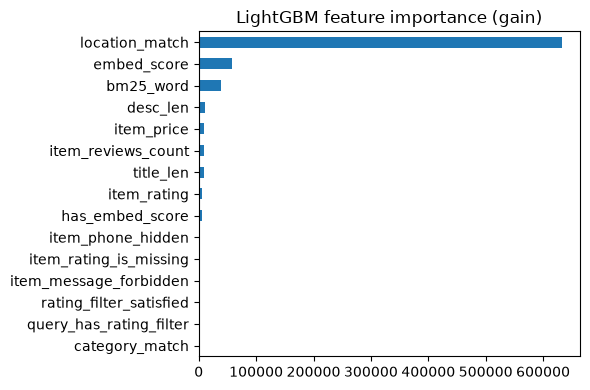

In [9]:
imp = pd.Series(model.feature_importance(importance_type="gain"), index=X_train.columns).sort_values(ascending=False)
print(imp)

imp.sort_values().plot(kind="barh", figsize=(6, 4))
plt.title("LightGBM feature importance (gain)")
plt.tight_layout()
plt.show()

## Оцениваем на отложенных запросах: baseline (BM25+гео) vs LightGBM-ре-ранкер

In [10]:
t0 = time.time()
X_eval, y_eval, groups_eval, q_col, item_col = build_examples(eval_uids, tq, item_arrays, tp, bm25, item_ids, gt, embed_lookup)
print(f"eval examples built in {time.time()-t0:.1f}s")
preds = model.predict(X_eval)

eval_df = pd.DataFrame({
    "query_uid": q_col, "item_id": item_col,
    "bm25": X_eval["bm25_word"].values, "loc": X_eval["location_match"].values,
    "pred": preds,
})
eval_df["score_bm25_geo"] = eval_df["bm25"] + 40.0 * eval_df["loc"]


def topk_by(col):
    return (
        eval_df.sort_values(col, ascending=False)
        .groupby("query_uid", sort=False)["item_id"].apply(lambda s: s.head(K).tolist())
    )


pred_bm25geo = topk_by("score_bm25_geo")
pred_lgb = topk_by("pred")

relevant_sets = [gt.get(u, set()) for u in eval_uids]
r_a, n_a = recall_at_k([pred_bm25geo.get(u, []) for u in eval_uids], relevant_sets)
r_b, n_b = recall_at_k([pred_lgb.get(u, []) for u in eval_uids], relevant_sets)
print(f"[baseline BM25+geo(boost=40), pool={CANDIDATE_POOL}]  recall@{K} = {r_a:.4f}  (n={n_a})")
print(f"[LightGBM re-ranker,          pool={CANDIDATE_POOL}]  recall@{K} = {r_b:.4f}  (n={n_b})")

eval examples built in 19.6s
[baseline BM25+geo(boost=40), pool=300]  recall@50 = 0.3979  (n=1500)
[LightGBM re-ranker,          pool=300]  recall@50 = 0.4010  (n=1500)


## Сохраняем модель

Если `recall@50` ре-ранкера выше baseline — можно смело использовать.
Если ниже или почти равен — возможно, стоит увеличить `N_TRAIN_QUERIES`,
добавить `embed_score` (прогнать `02_embed_and_retrieve.ipynb` в режиме
train) или поменять гиперпараметры LightGBM в ячейке обучения выше.

In [11]:
model.save_model("./reranker_lgb.txt")
print("сохранено ./reranker_lgb.txt -> используйте в generate_final_answer.py")

сохранено ./reranker_lgb.txt -> используйте в generate_final_answer.py


## Дальше

Запустите `generate_final_answer.py` — он подхватит `reranker_lgb.txt` автоматически (и `embed_candidates.parquet`, если он тоже посчитан в режиме benchmark).